
<div style="background:#0B1220; padding:28px; border-radius:16px; border:1px solid rgba(255,255,255,0.12);">
  <h1 style="color:#E6EDF3; margin:0; font-size:34px; text-align:center;">
    Weather and News Driven Energy Intelligence for Data Center Planning
  </h1>
  <p style="color:#C9D1D9; margin:10px 0 0 0; font-size:14px; text-align:center;">
    Open-source RSS and real-time weather analytics for operability, logistics, and grid stress mitigation
  </p>
  <p style="color:#C9D1D9; margin:6px 0 0 0; font-size:13px; text-align:center; opacity:0.92;">
    By DaScient
  </p>
</div>



## Purpose

This notebook is a practical package for building an always-on intelligence loop that connects:

- open-source news and RSS streams  
- real-time and forecast weather data  
- city-level data center planning signals  
- operability, logistics, and energy risk controls  

It helps answer:

- Where will heat, smoke, storms, and extreme cold raise cooling or resilience costs?  
- Which upcoming weather windows are likely to stress a grid and increase curtailment risk?  
- How can forecasts drive demand response, maintenance timing, and load shifting?  
- What public reporting and grid operator statements should be tracked as evidence for decisions?

This notebook runs end to end using public sources and no proprietary connectors.



## What you get

- RSS ingestion and normalization (dedupe, normalize, tag)  
- A clipping board with routing tags (grid, weather, policy, water, data centers)  
- Weather ingestion (forecast, optional alerts)  
- Weather-derived energy proxies (cooling burden, peak coincidence, risk windows)  
- City ranking views for near-term stress  
- Exports for dashboards and scheduled runs (CSV, JSON)  



## Core public sources used in this notebook

Weather

- Open-Meteo free weather API (no key required): https://open-meteo.com/  citeturn0search0  
- U.S. National Weather Service API (api.weather.gov): https://www.weather.gov/documentation/services-web-api  citeturn0search2  
- U.S. National Weather Service RSS libraries and active alerts RSS: https://www.weather.gov/rss/ and https://www.weather.gov/alerts/us.rss  citeturn0search1turn0search17  

Energy and grid

- U.S. EIA RSS feed directory: https://www.eia.gov/tools/rssfeeds/  citeturn0search3  
- PJM RSS feeds and Data Miner RSS guidance: https://www.pjm.com/about-pjm/newsroom/rss-feeds  citeturn2search2turn2search6  

News RSS

- Utility Dive RSS feed: https://www.utilitydive.com/feeds/news/  citeturn2search5  

Recent public context for clipping taxonomy and decision framing

- Grid connection delays and data center expansion:  citeturn1search10  
- Community and grid strain under data center boom:  citeturn1search8  
- Planning pressure and demand projections in the UK:  citeturn1news46  
- PJM region bill impacts and data center demand discussion:  citeturn1search7  
- Planning and accountability framing:  citeturn1search11  



## Contents

1. Setup  
2. City and site catalog  
3. RSS ingestion and normalization  
4. Clipping board (tagging, severity, routing)  
5. Weather ingestion (forecast and derived degree metrics)  
6. Weather-derived energy proxies  
7. Visualizations  
8. City ranking for near-term cooling stress  
9. Severe weather alerts ingestion (U.S.)  
10. Mitigation playbooks  
11. Exports  
12. Productionization notes  



## 1. Setup

Dependencies:

- requests  
- feedparser  
- pandas, numpy  
- matplotlib  

If you are in a clean environment, run the install cell once.


In [1]:

# Optional installs. Uncomment as needed.
# %pip install -q requests feedparser pandas numpy matplotlib python-dateutil


In [2]:

import os, json, time, math, hashlib
from typing import Dict, Any, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import feedparser

plt.rcParams["figure.dpi"] = 170
plt.rcParams["savefig.dpi"] = 240
plt.rcParams["font.size"] = 11

def utc_now_iso() -> str:
    return time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())

def stable_hash(obj: Any) -> str:
    blob = json.dumps(obj, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(blob).hexdigest()[:16]

RUN_TS = utc_now_iso()



## 2. City and site catalog

Edit this table as your footprint evolves.

Fields:

- lat/lon: used for weather calls  
- market: planning label  
- grid_hint: a reminder of relevant ISO/region  
- flags: corridor hazards and constraints  

Use flags to bind playbooks to sites (water stress, wildfire smoke, hurricane corridor).


In [3]:

CITY_CATALOG = pd.DataFrame([
    {"city":"Ashburn, VA (NoVA)","country":"US","lat":39.0438,"lon":-77.4874,"market":"Hyperscale","grid_hint":"PJM","flags":"interconnection_backlog;storm"},
    {"city":"Phoenix, AZ","country":"US","lat":33.4484,"lon":-112.0740,"market":"Hyperscale","grid_hint":"AZ","flags":"extreme_heat;water_stress"},
    {"city":"Dallas-Fort Worth, TX","country":"US","lat":32.7767,"lon":-96.7970,"market":"Hyperscale","grid_hint":"ERCOT","flags":"heat;storm"},
    {"city":"Atlanta, GA","country":"US","lat":33.7490,"lon":-84.3880,"market":"Major","grid_hint":"Southeast","flags":"heat;storm"},
    {"city":"Columbus, OH","country":"US","lat":39.9612,"lon":-82.9988,"market":"Major","grid_hint":"PJM","flags":"storm"},
    {"city":"Chicago, IL","country":"US","lat":41.8781,"lon":-87.6298,"market":"Major","grid_hint":"MISO/PJM","flags":"cold;storm"},
    {"city":"Portland, OR","country":"US","lat":45.5152,"lon":-122.6784,"market":"Major","grid_hint":"PNW","flags":"wildfire_smoke"},
    {"city":"Hillsboro, OR","country":"US","lat":45.5229,"lon":-122.9898,"market":"Hyperscale","grid_hint":"PNW","flags":"wildfire_smoke"},
    {"city":"Las Vegas, NV","country":"US","lat":36.1699,"lon":-115.1398,"market":"Emerging","grid_hint":"NV","flags":"extreme_heat;water_stress"},
    {"city":"New York / NJ","country":"US","lat":40.7128,"lon":-74.0060,"market":"Major","grid_hint":"NYISO/PJM","flags":"storm"},
    {"city":"Miami, FL","country":"US","lat":25.7617,"lon":-80.1918,"market":"Major","grid_hint":"FRCC","flags":"hurricane;flood"},
    {"city":"New Orleans, LA","country":"US","lat":29.9511,"lon":-90.0715,"market":"Emerging","grid_hint":"MISO","flags":"hurricane;flood"},
    {"city":"Denver, CO","country":"US","lat":39.7392,"lon":-104.9903,"market":"Emerging","grid_hint":"Rockies","flags":"wildfire_smoke;hail"},
    {"city":"London, UK","country":"UK","lat":51.5072,"lon":-0.1276,"market":"Major","grid_hint":"GB","flags":"grid_capacity;heat"},
    {"city":"Dublin, IE","country":"IE","lat":53.3498,"lon":-6.2603,"market":"Major","grid_hint":"IE","flags":"grid_capacity"},
    {"city":"Frankfurt, DE","country":"DE","lat":50.1109,"lon":8.6821,"market":"Major","grid_hint":"DE","flags":"grid_capacity"},
    {"city":"Singapore","country":"SG","lat":1.3521,"lon":103.8198,"market":"Major","grid_hint":"SG","flags":"heat;humidity;water"},
    {"city":"Sydney, AU","country":"AU","lat":-33.8688,"lon":151.2093,"market":"Major","grid_hint":"AU-NSW","flags":"heat;wildfire"},
    {"city":"Melbourne, AU","country":"AU","lat":-37.8136,"lon":144.9631,"market":"Major","grid_hint":"AU-VIC","flags":"heat"},
])

CITY_CATALOG


,city,country,lat,lon,market,grid_hint,flags
0,"Ashburn, VA (NoVA)",US,39.0438,-77.4874,Hyperscale,PJM,interconnection_backlog;storm
1,"Phoenix, AZ",US,33.4484,-112.0740,Hyperscale,AZ,extreme_heat;water_stress
2,"Dallas-Fort Worth, TX",US,32.7767,-96.7970,Hyperscale,ERCOT,heat;storm
3,"Atlanta, GA",US,33.7490,-84.3880,Major,Southeast,heat;storm
4,"Columbus, OH",US,39.9612,-82.9988,Major,PJM,storm
5,"Chicago, IL",US,41.8781,-87.6298,Major,MISO/PJM,cold;storm
6,"Portland, OR",US,45.5152,-122.6784,Major,PNW,wildfire_smoke
7,"Hillsboro, OR",US,45.5229,-122.9898,Hyperscale,PNW,wildfire_smoke
8,"Las Vegas, NV",US,36.1699,-115.1398,Emerging,NV,extreme_heat;water_stress
9,New York / NJ,US,40.7128,-74.0060,Major,NYISO/PJM,storm



## 3. RSS ingestion and normalization

RSS is treated as an evidence stream.

Goals:

- fetch multiple feeds  
- normalize title, date, summary, link  
- deduplicate  
- tag items for routing and triage


In [5]:

RSS_SOURCES = [
    {"source":"EIA Today in Energy", "url":"https://www.eia.gov/rss/todayinenergy.xml"},
    {"source":"EIA Press Releases", "url":"https://www.eia.gov/pressroom/releases.php"},
    {"source":"Utility Dive", "url":"https://www.utilitydive.com/feeds/news/"},
    {"source":"NWS Active Alerts (US)", "url":"https://www.weather.gov/alerts/us.rss"},
    {"source":"PJM Newsroom", "url":"https://www.pjm.com/about-pjm/newsroom/rss-feeds/~/rss.aspx?feed=News%20Releases"},
]

def fetch_rss(url: str, timeout_s: int = 30):
    headers = {"User-Agent":"DaScient-RSS-Weather-Energy-Notebook/1.0"}
    resp = requests.get(url, headers=headers, timeout=timeout_s)
    resp.raise_for_status()
    return feedparser.parse(resp.content)

def parse_entry(e):
    title = (e.get("title", "") or "").strip()
    link = (e.get("link", "") or "").strip()
    summary = ((e.get("summary", "") or e.get("description", "") or "")).strip()
    published = (e.get("published", "") or e.get("updated", "") or "").strip()
    return {"title": title, "link": link, "summary": summary, "published_raw": published}

def pull_all_rss(sources, limit_per_feed: int = 40) -> pd.DataFrame:
    rows = []
    for s in sources:
        feed = fetch_rss(s["url"])
        for e in (feed.entries or [])[:limit_per_feed]:
            row = parse_entry(e)
            row["source"] = s["source"]
            row["feed_url"] = s["url"]
            rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["id"] = df.apply(lambda r: stable_hash({"t":r["title"], "l":r["link"]}), axis=1)
    return df.drop_duplicates("id").reset_index(drop=True)

rss_df = pull_all_rss(RSS_SOURCES, limit_per_feed=35)
rss_df.head(10)


,title,link,summary,published_raw,source,feed_url,id
0,Most natural gas pipelines built in 2025 conne...,https://www.eia.gov/todayinenergy/detail.php?i...,Natural gas pipeline projects completed in the...,"Wed, 25 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,ef972041db38c4f0
1,"Ten years after first Sabine Pass cargo, U.S. ...",https://www.eia.gov/todayinenergy/detail.php?i...,"Ten years ago, on February 24, 2016, the first...","Tue, 24 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,94ec87bb308f5d70
2,Retirement delays of U.S. electric generating ...,https://www.eia.gov/todayinenergy/detail.php?i...,U.S. power plant owners and operators plan to ...,"Mon, 23 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,d7f7761a62721c8b
3,New U.S. electric generating capacity expected...,https://www.eia.gov/todayinenergy/detail.php?i...,U.S. power plant developers and operators plan...,"Fri, 20 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,7195e84bf1788b78
4,Enhanced geothermal systems could expand geoth...,https://www.eia.gov/todayinenergy/detail.php?i...,The first large-scale commercial enhanced geot...,"Thu, 19 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,5202f03f35d24d31
5,Maritime exports of petroleum products increas...,https://www.eia.gov/todayinenergy/detail.php?i...,U.S. exports of refined petroleum products car...,"Tue, 17 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,58362846cf2702fa
6,U.S. natural gas production to reach record hi...,https://www.eia.gov/todayinenergy/detail.php?i...,We forecast that U.S. natural gas marketed pro...,"Fri, 13 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,0b157a6a1bc56cd6
7,Many states slightly increased their taxes and...,https://www.eia.gov/todayinenergy/detail.php?i...,State taxes and fees on motor gasoline as of J...,"Thu, 12 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,dbd39aa53460f9c7
8,EIA forecasts lower oil prices in 2026 and 202...,https://www.eia.gov/todayinenergy/detail.php?i...,We forecast that production of petroleum and o...,"Wed, 11 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,32846ebb84e3a8d9
9,Electric vehicle sales fell as hybrid vehicle ...,https://www.eia.gov/todayinenergy/detail.php?i...,About 22% of light-duty vehicles sold in 2025 ...,"Mon, 09 Feb 2026 09:00:00 EST",EIA Today in Energy,https://www.eia.gov/rss/todayinenergy.xml,f50b7c8bda8e2e62



## 4. Clipping board

Transparent tagging is used for routing:

- data_center  
- grid  
- energy  
- weather  
- water  
- policy  

Severity is a simple weighted score designed for triage. Edit weights as needed.


In [6]:

KEYWORDS = {
    "data_center": ["data center", "datacenter", "hyperscale", "colocation", "colo", "server farm"],
    "grid": ["grid", "transmission", "interconnection", "capacity", "substation", "utility", "tariff", "PJM", "ERCOT", "MISO", "NYISO", "ISO"],
    "energy": ["power", "electricity", "gas", "nuclear", "renewable", "load growth", "demand response", "curtailment"],
    "weather": ["heat", "cold", "storm", "hurricane", "tornado", "snow", "flood", "drought", "wildfire", "smoke"],
    "water": ["water", "cooling", "recycled", "wue", "withdrawal", "drought"],
    "policy": ["regulation", "commission", "DOE", "EPA", "loan", "subsidy", "permit", "planning", "zoning"],
}

def normalize_text(s: str) -> str:
    return (s or "").lower()

def tag_text(title: str, summary: str) -> Dict[str,int]:
    text = normalize_text(title) + " " + normalize_text(summary)
    out = {}
    for k, words in KEYWORDS.items():
        out[k] = int(any(w in text for w in words))
    return out

def score_severity(source: str, tags: Dict[str,int]) -> float:
    base = 0.0
    if "NWS" in source:
        base += 2.0
    if "PJM" in source:
        base += 1.2
    if "EIA" in source:
        base += 1.0
    base += 1.0*tags["grid"] + 1.0*tags["energy"] + 0.8*tags["weather"] + 0.6*tags["data_center"] + 0.6*tags["water"] + 0.5*tags["policy"]
    return float(base)

if not rss_df.empty:
    for i, r in rss_df.iterrows():
        tags = tag_text(r["title"], r["summary"])
        for k,v in tags.items():
            rss_df.loc[i, k] = v
        rss_df.loc[i, "severity"] = score_severity(r["source"], tags)

    board_cols = ["severity","source","published_raw","title","link","grid","energy","weather","data_center","water","policy"]
    board = rss_df.sort_values("severity", ascending=False)[board_cols].head(60)
    board
else:
    print("No RSS entries retrieved. Check network access or feed URLs.")



## 5. Weather ingestion

Open-Meteo is used for forecasts (no API key). citeturn0search0

We pull:

- temperature at 2m  
- relative humidity  
- dew point  
- wind speed  
- precipitation  

Then we compute cooling and heating degree hours (base 18C by default).


In [7]:

def open_meteo_forecast(lat: float, lon: float, days: int = 14) -> pd.DataFrame:
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "temperature_2m,relative_humidity_2m,dew_point_2m,wind_speed_10m,precipitation",
        "timezone": "UTC",
        "forecast_days": int(days),
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    j = r.json()
    hourly = j.get("hourly", {})
    t = pd.to_datetime(hourly.get("time", []), utc=True)
    return pd.DataFrame({
        "time_utc": t,
        "temp_c": hourly.get("temperature_2m", []),
        "rh_pct": hourly.get("relative_humidity_2m", []),
        "dew_c": hourly.get("dew_point_2m", []),
        "wind_ms": hourly.get("wind_speed_10m", []),
        "precip_mm": hourly.get("precipitation", []),
    })

def cooling_degree_hours(temp_c: pd.Series, base_c: float = 18.0) -> pd.Series:
    return np.maximum(temp_c - base_c, 0.0)

def heating_degree_hours(temp_c: pd.Series, base_c: float = 18.0) -> pd.Series:
    return np.maximum(base_c - temp_c, 0.0)

example_city = CITY_CATALOG.iloc[0].to_dict()
fc = open_meteo_forecast(example_city["lat"], example_city["lon"], days=10)
fc["cdh"] = cooling_degree_hours(fc["temp_c"])
fc["hdh"] = heating_degree_hours(fc["temp_c"])
fc.head()


,time_utc,temp_c,rh_pct,dew_c,wind_ms,precip_mm,cdh,hdh
0,2026-02-27 00:00:00+00:00,5.3,88,3.5,4.1,0.0,0.0,12.7
1,2026-02-27 01:00:00+00:00,5.5,85,3.2,2.8,0.0,0.0,12.5
2,2026-02-27 02:00:00+00:00,4.9,88,3.1,1.8,0.0,0.0,13.1
3,2026-02-27 03:00:00+00:00,3.5,87,1.5,4.5,0.0,0.0,14.5
4,2026-02-27 04:00:00+00:00,2.7,95,1.9,1.8,0.0,0.0,15.3



## 6. Weather-derived energy proxies

We estimate cooling power using a planning coefficient:

- cooling_kW ~= IT_kW * (k_cdh * CDH + k_humid * humidity_penalty)

This is a proxy for comparing cities and windows, not a replacement for facility modeling.

Calibrate coefficients with telemetry when available.


In [8]:

def estimate_cooling_kw(it_kw: float, cdh: pd.Series, rh_pct: pd.Series, k_cdh: float = 0.010, k_humid: float = 0.002) -> pd.Series:
    humid_penalty = np.maximum((rh_pct - 60.0) / 40.0, 0.0)
    return it_kw * (k_cdh * cdh + k_humid * humid_penalty)

def estimate_facility_kw(it_kw: float, cooling_kw: pd.Series, pue_floor: float = 1.08) -> pd.Series:
    return it_kw * pue_floor + cooling_kw

def peak_coincidence_factor(times_utc: pd.Series, facility_kw: pd.Series, peak_hours_utc: Tuple[int,int] = (16, 20)) -> float:
    start_h, end_h = peak_hours_utc
    peak_mask = (times_utc.dt.hour >= start_h) & (times_utc.dt.hour <= end_h)
    if int(peak_mask.sum()) == 0:
        return float("nan")
    return float(np.mean(facility_kw[peak_mask]) / max(float(np.mean(facility_kw)), 1e-9))

PLANNED_IT_KW = 50_000

fc2 = fc.copy()
fc2["cooling_kw"] = estimate_cooling_kw(PLANNED_IT_KW, fc2["cdh"], fc2["rh_pct"])
fc2["facility_kw_est"] = estimate_facility_kw(PLANNED_IT_KW, fc2["cooling_kw"])
pcf = peak_coincidence_factor(fc2["time_utc"], fc2["facility_kw_est"])
pcf


1.0011583438888996


## 7. Visualizations

High-fidelity figures:

- forecast temperature  
- cooling degree hours  
- estimated cooling and facility power  
- precipitation


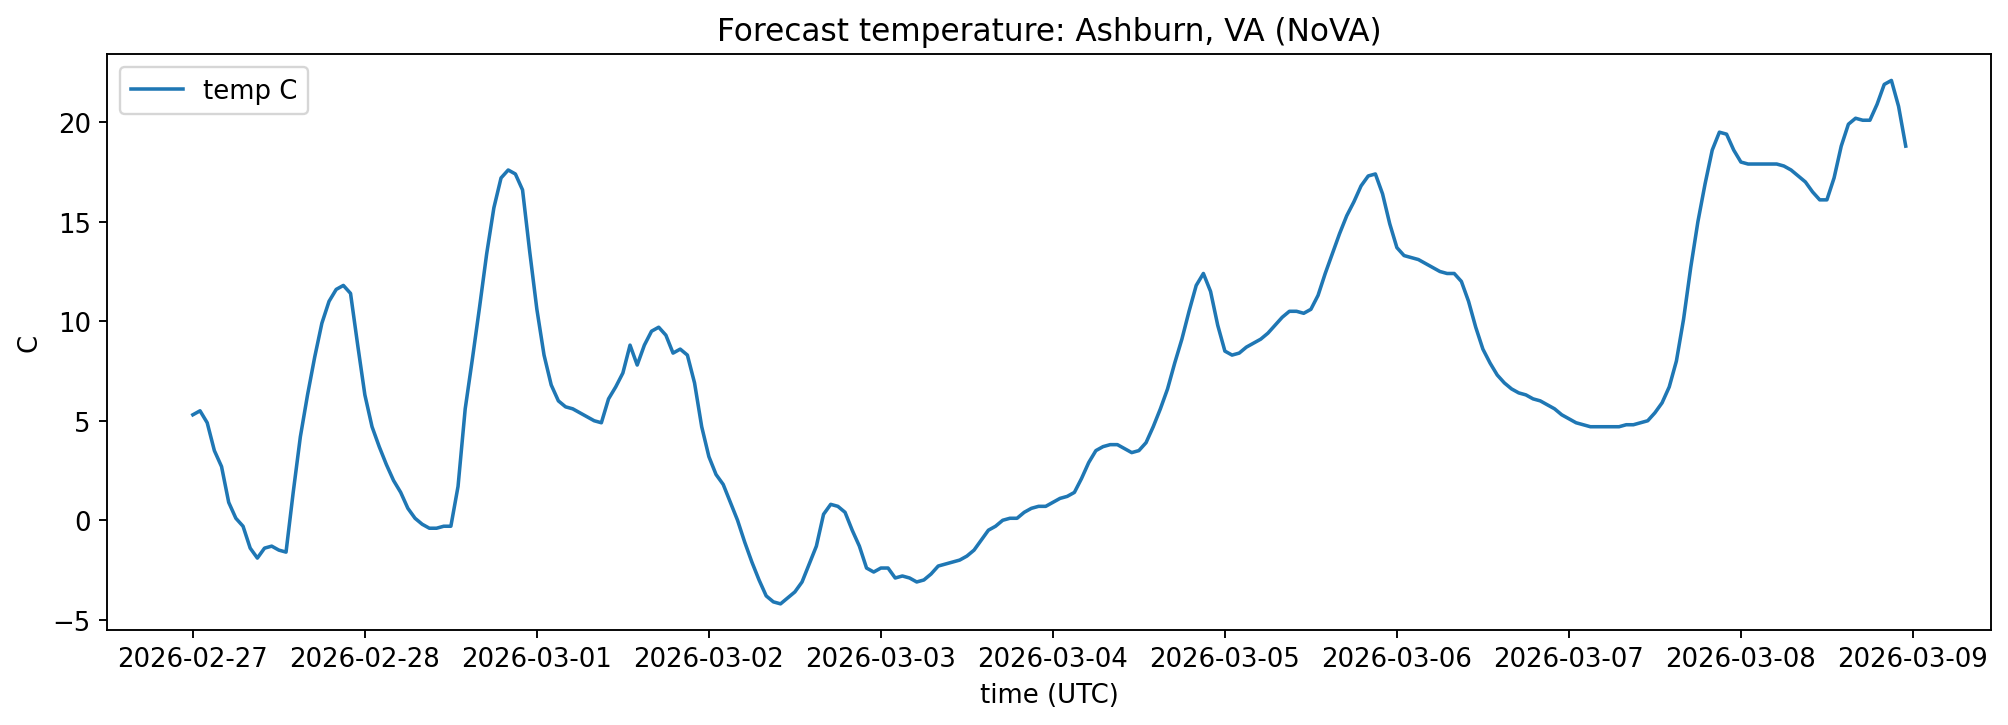

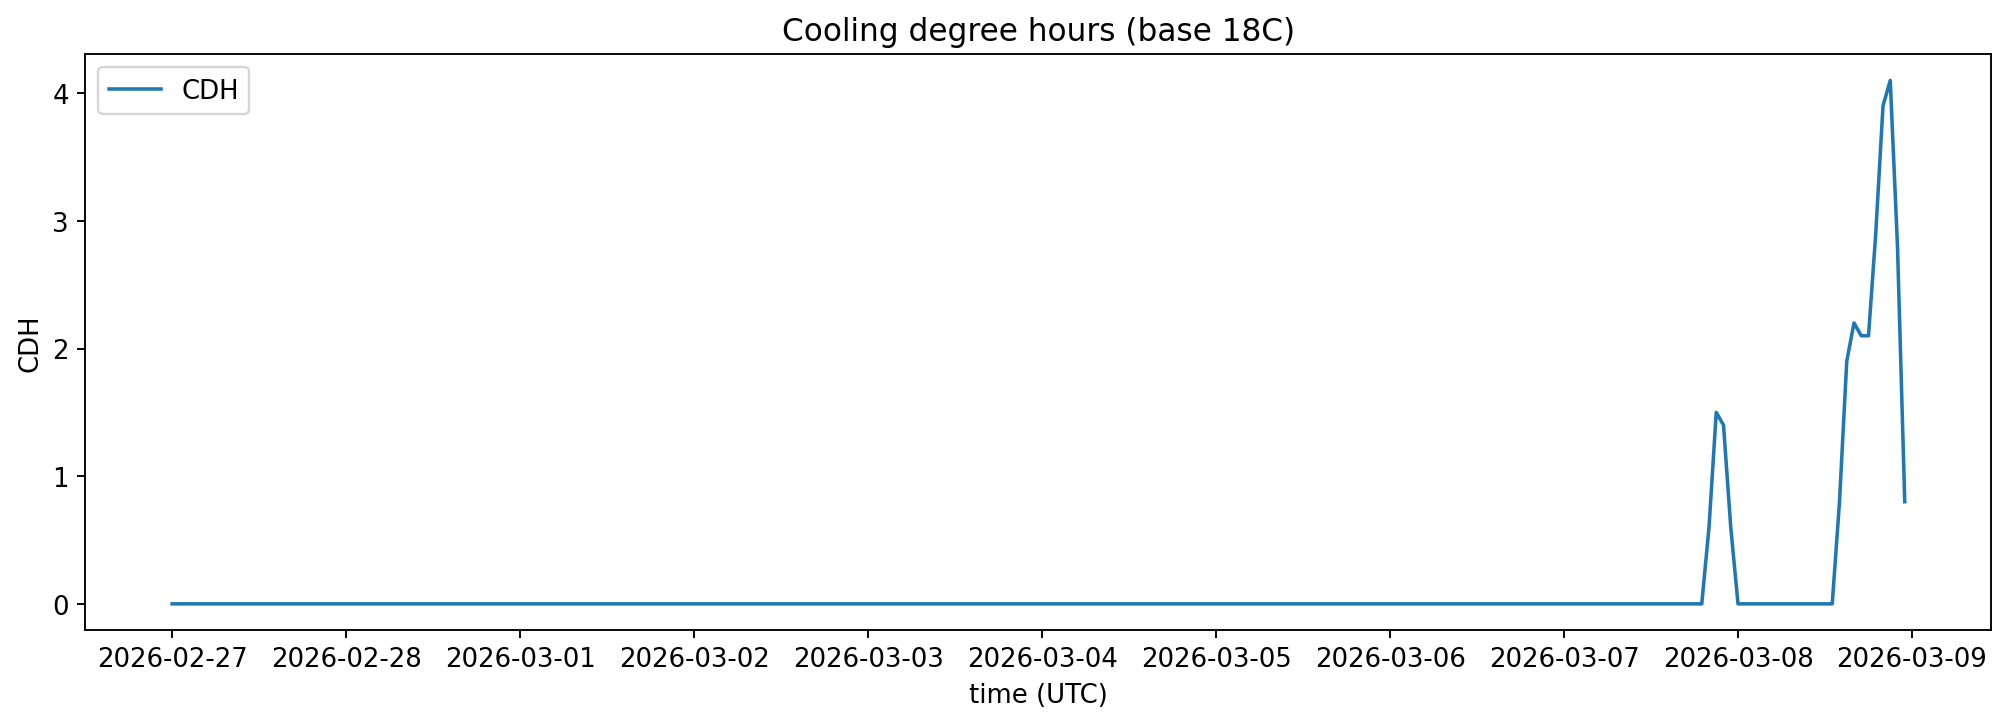

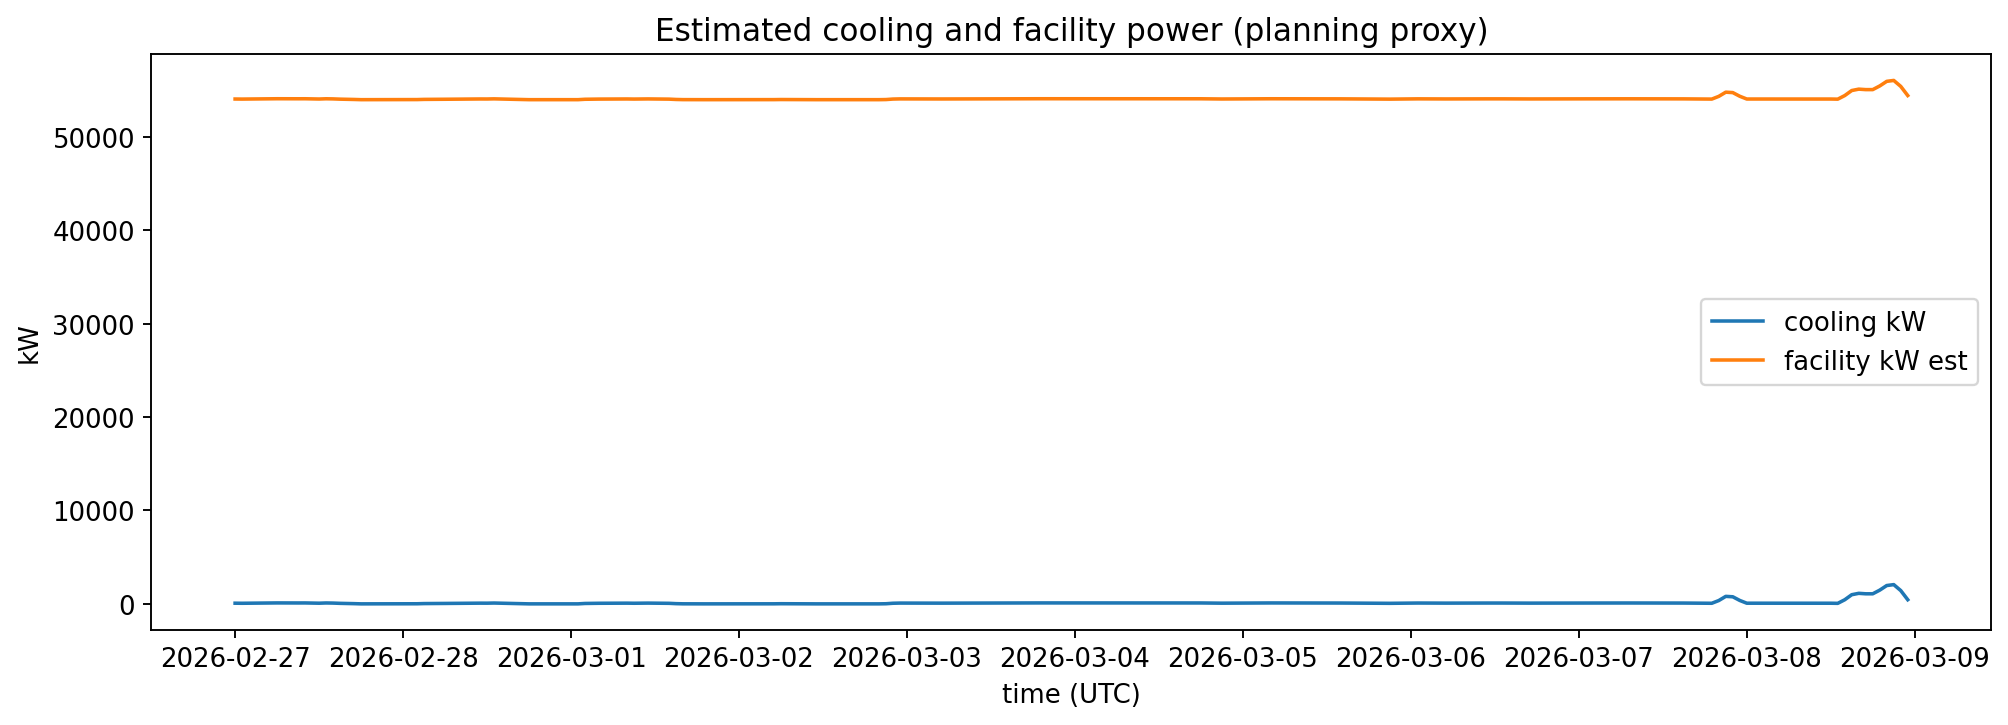

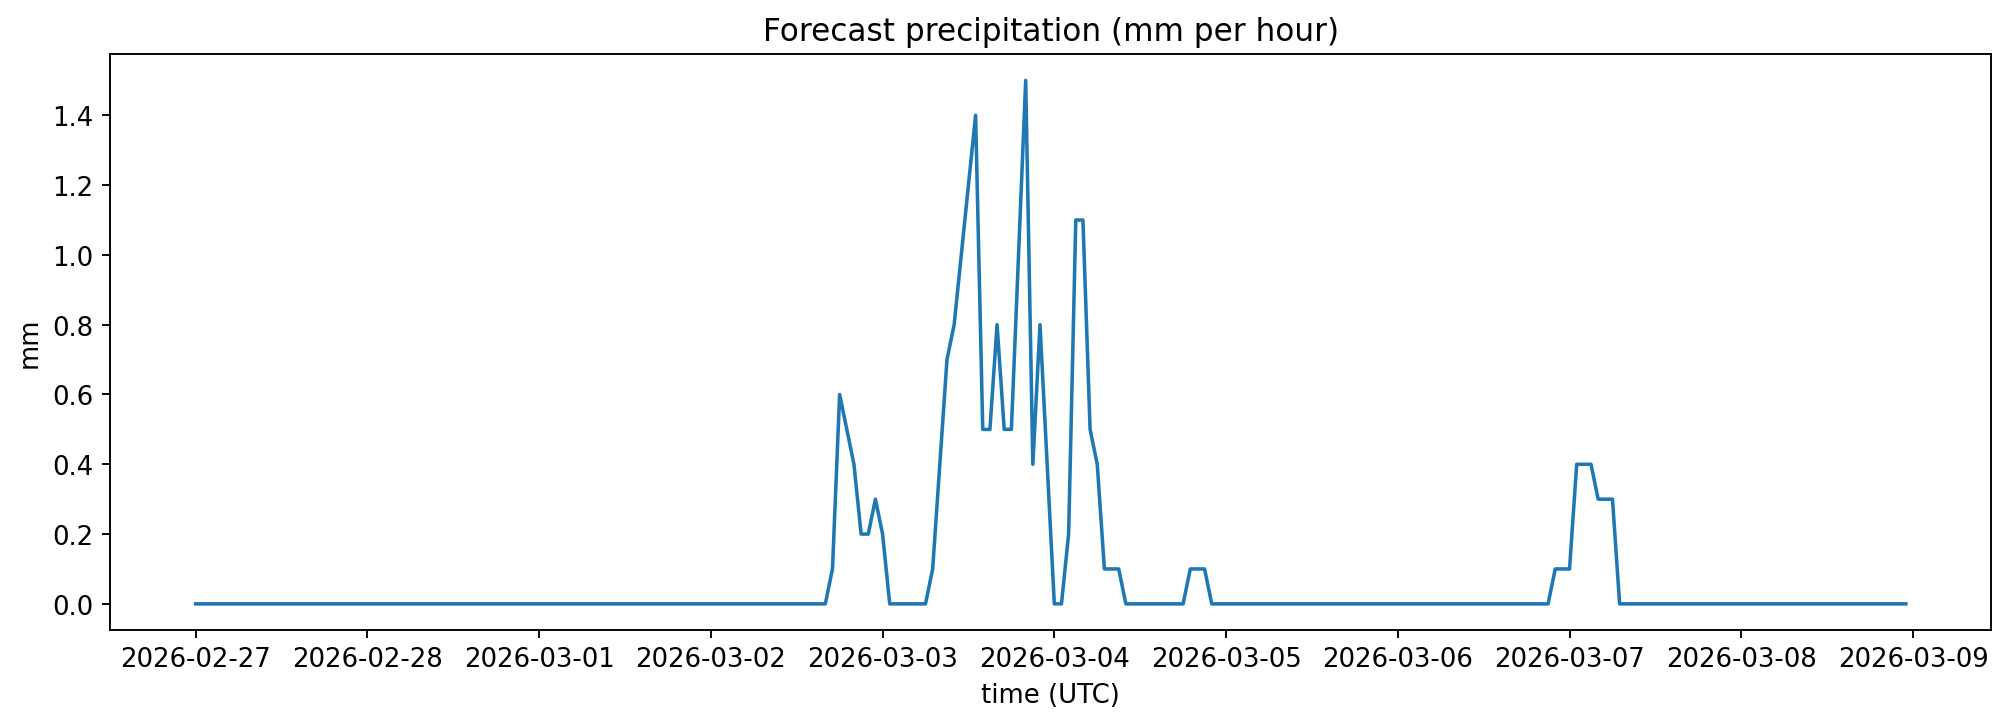

In [9]:

plt.figure(figsize=(12,4.4))
plt.plot(fc2["time_utc"], fc2["temp_c"], label="temp C")
plt.title(f"Forecast temperature: {example_city['city']}")
plt.xlabel("time (UTC)")
plt.ylabel("C")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4.4))
plt.plot(fc2["time_utc"], fc2["cdh"], label="CDH")
plt.title("Cooling degree hours (base 18C)")
plt.xlabel("time (UTC)")
plt.ylabel("CDH")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4.4))
plt.plot(fc2["time_utc"], fc2["cooling_kw"], label="cooling kW")
plt.plot(fc2["time_utc"], fc2["facility_kw_est"], label="facility kW est")
plt.title("Estimated cooling and facility power (planning proxy)")
plt.xlabel("time (UTC)")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4.4))
plt.plot(fc2["time_utc"], fc2["precip_mm"])
plt.title("Forecast precipitation (mm per hour)")
plt.xlabel("time (UTC)")
plt.ylabel("mm")
plt.tight_layout()
plt.show()



## 8. City ranking for near-term cooling stress

This ranks cities over a forecast window by cooling energy proxy.

Note: this calls the weather API for each city. Keep the catalog tight, cache results, or run in batches.


In [10]:

def city_forecast_summary(city_row: Dict[str,Any], planned_it_kw: float, days: int = 7) -> Dict[str, Any]:
    fc = open_meteo_forecast(city_row["lat"], city_row["lon"], days=days)
    fc["cdh"] = cooling_degree_hours(fc["temp_c"])
    fc["cooling_kw"] = estimate_cooling_kw(planned_it_kw, fc["cdh"], fc["rh_pct"])
    cooling_kwh = float(np.sum(fc["cooling_kw"]))  # hourly kW sum approximates kWh
    return {
        "city": city_row["city"],
        "market": city_row["market"],
        "grid_hint": city_row["grid_hint"],
        "flags": city_row["flags"],
        "cdh_sum": float(np.sum(fc["cdh"])),
        "cdh_p99": float(np.quantile(fc["cdh"], 0.99)) if len(fc) else float("nan"),
        "rh_p50": float(np.median(fc["rh_pct"])) if len(fc) else float("nan"),
        "cooling_kwh_proxy": cooling_kwh,
    }

DAYS = 7
planned_it_kw = 50_000

summaries = []
for _, r in CITY_CATALOG.iterrows():
    try:
        summaries.append(city_forecast_summary(r.to_dict(), planned_it_kw, days=DAYS))
    except Exception as e:
        summaries.append({"city": r["city"], "error": str(e)[:160]})

rank_df = pd.DataFrame(summaries)
if "error" in rank_df.columns:
    rank_df = rank_df[rank_df["error"].isna()].copy()
rank_df = rank_df.sort_values("cooling_kwh_proxy", ascending=False).reset_index(drop=True)
rank_df.head(12)


,city,market,grid_hint,flags,cdh_sum,cdh_p99,rh_p50,cooling_kwh_proxy
0,Singapore,Major,SG,heat;humidity;water,1593.7,14.631,83.0,805312.5
1,"Phoenix, AZ",Hyperscale,AZ,extreme_heat;water_stress,1102.1,15.731,16.5,551050.0
2,"Miami, FL",Major,FRCC,hurricane;flood,884.7,8.033,79.0,450777.5
3,"Sydney, AU",Major,AU-NSW,heat;wildfire,876.6,18.998,77.5,444855.0
4,"Melbourne, AU",Major,AU-VIC,heat,698.1,12.366,76.0,355802.5
5,"New Orleans, LA",Emerging,MISO,hurricane;flood,498.9,10.932,84.0,257370.0
6,"Las Vegas, NV",Emerging,NV,extreme_heat;water_stress,502.0,12.364,24.0,251000.0
7,"Dallas-Fort Worth, TX",Hyperscale,ERCOT,heat;storm,453.3,9.132,67.0,231472.5
8,"Atlanta, GA",Major,Southeast,heat;storm,83.4,7.498,78.0,49395.0
9,"Denver, CO",Emerging,Rockies,wildfire_smoke;hail,20.3,2.366,36.5,12117.5


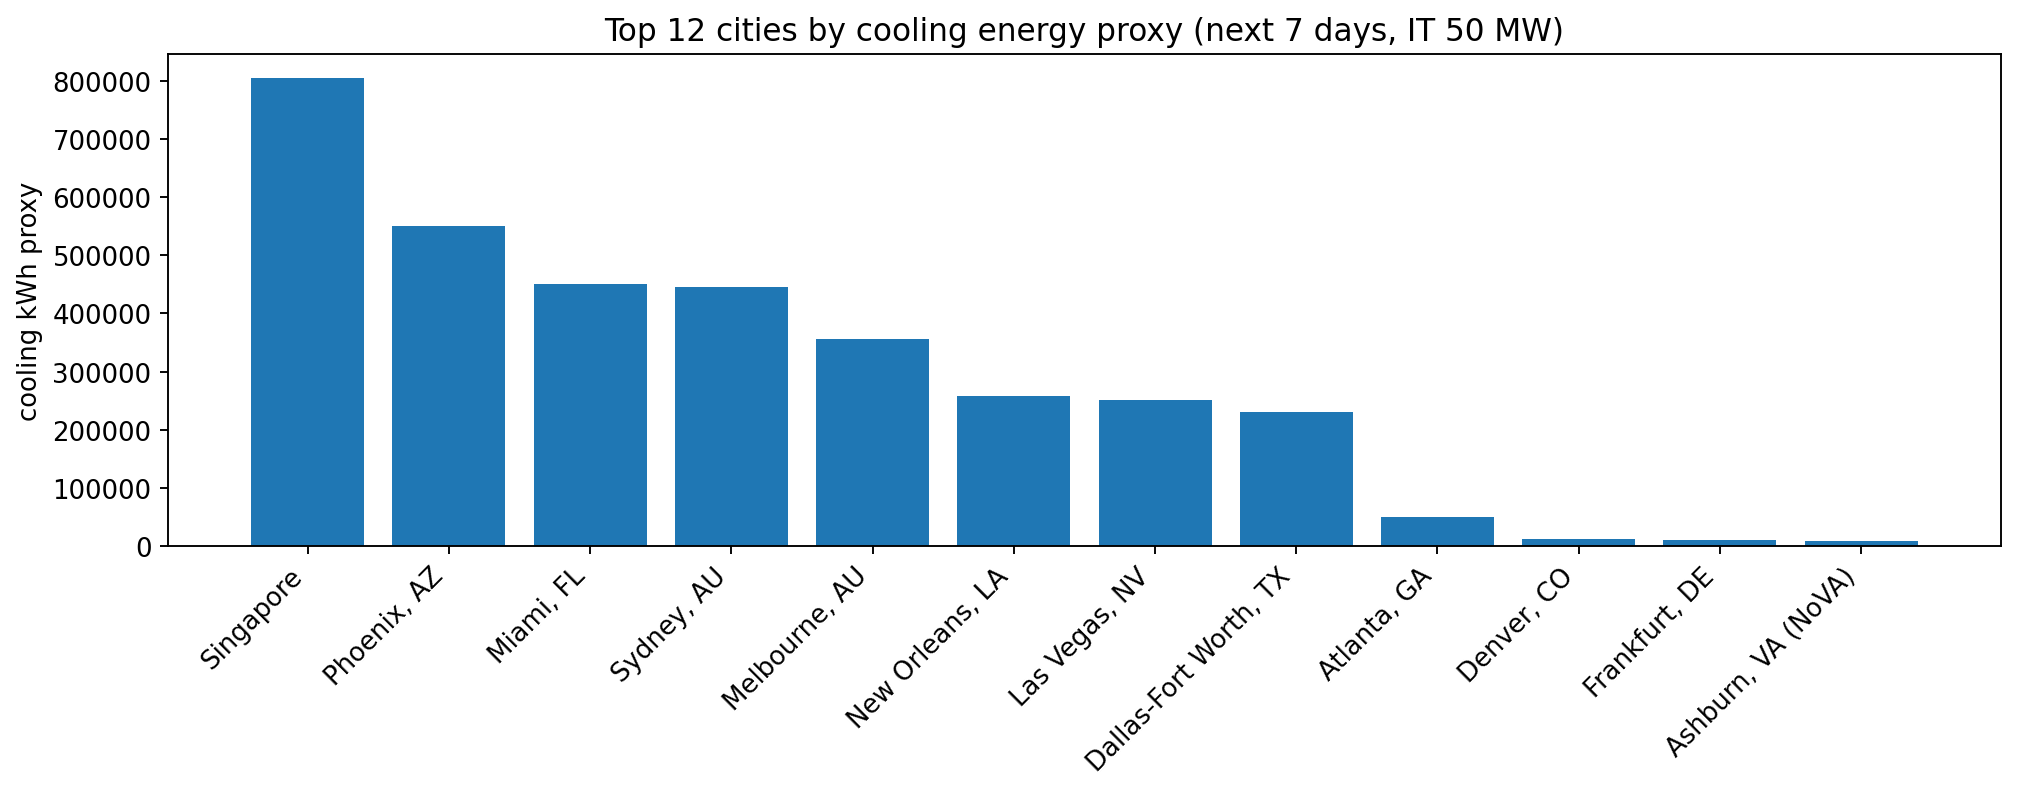

In [11]:

plt.figure(figsize=(12,4.8))
plt.bar(rank_df["city"].head(12), rank_df["cooling_kwh_proxy"].head(12))
plt.xticks(rotation=45, ha="right")
plt.title(f"Top 12 cities by cooling energy proxy (next {DAYS} days, IT {planned_it_kw/1000:.0f} MW)")
plt.ylabel("cooling kWh proxy")
plt.tight_layout()
plt.show()



## 9. Severe weather alerts ingestion (U.S.)

NWS active alerts RSS is used for a national feed. citeturn0search17

For site-specific alerts, expand to API point queries with api.weather.gov. citeturn0search2


In [12]:

def pull_nws_active_alerts(limit: int = 80) -> pd.DataFrame:
    feed = fetch_rss("https://www.weather.gov/alerts/us.rss")
    rows = []
    for e in (feed.entries or [])[:limit]:
        rows.append({
            "title": e.get("title",""),
            "summary": (e.get("summary","") or ""),
            "link": e.get("link",""),
            "published_raw": e.get("published","") or e.get("updated",""),
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["id"] = df.apply(lambda r: stable_hash({"t":r["title"], "l":r["link"]}), axis=1)
    return df.drop_duplicates("id").reset_index(drop=True)

alerts_df = pull_nws_active_alerts(limit=60)
alerts_df.head(25)


""



## 10. Mitigation playbooks

Peak and heat protocol

- If forecast CDH rises sharply and peak coincidence is high:
  - shift batch and training away from peak windows
  - raise admission control thresholds for low priority traffic
  - stage on-call and facilities staffing

Storm protocol

- If severe storm alerts appear in the corridor:
  - freeze non-essential maintenance
  - confirm generator fuel and UPS readiness
  - pre-stage critical spare parts

Water stress protocol

- If a prolonged heat window coincides with water-stress flags:
  - prefer economization windows when available
  - review recycled water and withdrawal constraints
  - track WUE targets alongside energy targets



## 11. Exports

Exports are designed for scheduled runs:

- clipping_board.csv  
- city_ranking.csv  
- run_artifact.json


In [ ]:

from pathlib import Path

out_dir = Path("./runs") / "dascient_weather_energy_dc_planning"
out_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "run_ts_utc": RUN_TS,
    "sources": RSS_SOURCES,
    "city_count": int(len(CITY_CATALOG)),
    "ranking_days": int(DAYS),
    "planned_it_kw": float(planned_it_kw),
    "example_city": example_city["city"],
}

if "board" in globals():
    board.to_csv(out_dir / "clipping_board.csv", index=False)
rank_df.to_csv(out_dir / "city_ranking.csv", index=False)

with open(out_dir / "run_artifact.json", "w", encoding="utf-8") as f:
    json.dump(artifact, f, indent=2, sort_keys=True)

str(out_dir), artifact



## 12. Productionization notes

- Scheduler: 30 to 60 minutes for weather and alerts; daily for ranking  
- Storage: JSONL for RSS; parquet for hourly weather; keep raw payloads  
- Caching: cache Open-Meteo results to reduce API load  
- Routing: send high severity items to Slack/email; link to playbooks  
- Governance: every automated action must be reversible; log decisions and thresholds
